# Practical 2: Part-of-Speech (POS) Tagging in NLP

**Students:** Kevin Sánchez & Jhony Peñaherrera

**Course:** Natural Language Processing

---

## Introduction

Part-of-Speech (POS) tagging is a fundamental task in Natural Language Processing that involves assigning grammatical categories (noun, verb, adjective, etc.) to each token in a sentence. This seemingly simple task is crucial for many downstream NLP applications.

### Why is POS Tagging Important?

POS tagging serves as a building block for various NLP tasks:

- **Syntactic Parsing:** Understanding sentence structure requires knowing word categories
- **Named Entity Recognition (NER):** Proper nouns are often entities of interest
- **Information Extraction:** Extracting relationships between entities relies on verbs and prepositions
- **Machine Translation:** Different languages have different word order rules based on POS
- **Text Mining and Sentiment Analysis:** Adjectives and adverbs carry sentiment information
- **Speech Recognition:** Disambiguating homophones (e.g., "read" as verb vs. past tense)

### Tag Sets Used

This practical works with two standard tag sets:

1. **Penn Treebank Tags:** English-specific, with 36 tags (e.g., NN, VBZ, JJ, DT)
2. **Universal POS Tags:** Cross-linguistic, with 17 tags (e.g., NOUN, VERB, ADJ, DET)

### Objectives

By the end of this lab, you will be able to:

1. Apply pre-trained POS taggers in English and Spanish
2. Train statistical POS taggers (Unigram and Bigram models)
3. Evaluate tagger performance using standard metrics
4. Perform error analysis and understand tagger limitations
5. Compare different tagging approaches and their trade-offs

---
## Initial Setup

In [1]:
# Install required libraries
!pip install -q spacy nltk scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Download spaCy Spanish model
!python -m spacy download es_core_news_sm

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     --------------------------------------- 0.0/12.9 MB 330.3 kB/s eta 0:00:39
     ---------------------------------------- 0.2/12.9 MB 1.0 MB/s eta 0:00:13
     - -------------------------------------- 0.4/12.9 MB 2.3 MB/s eta 0:00:06
     - -------------------------------------- 0.5/12.9 MB 2.6 MB/s eta 0:00:05
     -- ------------------------------------- 0.7/12.9 MB 2.5 MB/s eta 0:00:05
     -- ------------------------------------- 0.9/12.9 MB 2.8 MB/s eta 0:00:05
     --- ------------------------------------ 1.1/12.9 MB 3.1 MB/s eta 0:00:04
     ---- ----------------------------------- 1.5/12.9 MB 3.7 MB/s eta 0:00:04
     ------ --------------------------------- 1.9/12.9 MB 4.3 MB/s eta 0:00:03
     ------ --------------------------------- 2.2/12.9 MB 4.4 MB/s eta 0


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Standard imports
import nltk
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings

# NLTK specific imports
from nltk.tokenize import word_tokenize
from nltk.corpus import treebank
from nltk.tag import UnigramTagger, BigramTagger, DefaultTagger

# Scikit-learn for metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [4]:
# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('treebank', quiet=True)
nltk.download('universal_tagset', quiet=True)

print("✓ NLTK resources downloaded")

✓ NLTK resources downloaded


In [5]:
# Load spaCy Spanish model
nlp_es = spacy.load("es_core_news_sm")
print("✓ spaCy Spanish model loaded")

✓ spaCy Spanish model loaded


---
## Exercise 1: Basic - Tokenization & POS Tagging

In this exercise, we will:
1. Tokenize and tag sentences in both English and Spanish
2. Identify the most frequent POS tag in each sentence
3. Report tagging errors or interesting observations

### 1.1 - Define Test Sentences

In [6]:
# Test sentences from lab instructions
english_sentence = "Researchers are evaluating different models for natural language processing."
spanish_sentence = "Los investigadores están evaluando diferentes modelos."

print("English:", english_sentence)
print("Spanish:", spanish_sentence)

English: Researchers are evaluating different models for natural language processing.
Spanish: Los investigadores están evaluando diferentes modelos.


### 1.2 - English POS Tagging with NLTK

NLTK uses the Penn Treebank tag set for English. The tagger is based on a Maximum Entropy classifier trained on the Wall Street Journal corpus.

In [7]:
# Tokenization
eng_tokens = word_tokenize(english_sentence)

# POS tagging
eng_pos_tags = nltk.pos_tag(eng_tokens)

print("=" * 60)
print("ENGLISH POS TAGGING (NLTK - Penn Treebank)")
print("=" * 60)
print(f"\nSentence: {english_sentence}\n")
print("Tokens and POS tags:")
for token, tag in eng_pos_tags:
    print(f"  {token:20s} -> {tag}")

ENGLISH POS TAGGING (NLTK - Penn Treebank)

Sentence: Researchers are evaluating different models for natural language processing.

Tokens and POS tags:
  Researchers          -> NNS
  are                  -> VBP
  evaluating           -> VBG
  different            -> JJ
  models               -> NNS
  for                  -> IN
  natural              -> JJ
  language             -> NN
  processing           -> NN
  .                    -> .


#### Penn Treebank Tag Reference

Common tags in our sentence:
- **NNS:** Noun, plural (e.g., "Researchers", "models")
- **VBP:** Verb, non-3rd person singular present (e.g., "are")
- **VBG:** Verb, gerund or present participle (e.g., "evaluating", "processing")
- **JJ:** Adjective (e.g., "different", "natural")
- **NN:** Noun, singular (e.g., "language")
- **IN:** Preposition or subordinating conjunction (e.g., "for")

In [8]:
# Most frequent tag in English sentence
eng_tag_freq = Counter([tag for _, tag in eng_pos_tags])

print("\nTag frequency distribution:")
for tag, count in eng_tag_freq.most_common():
    print(f"  {tag}: {count}")

most_common_tag = eng_tag_freq.most_common(1)[0]
print(f"\nMost frequent tag: {most_common_tag[0]} (appears {most_common_tag[1]} times)")


Tag frequency distribution:
  NNS: 2
  JJ: 2
  NN: 2
  VBP: 1
  VBG: 1
  IN: 1
  .: 1

Most frequent tag: NNS (appears 2 times)


### 1.3 - Spanish POS Tagging with spaCy

spaCy uses Universal POS tags, which are consistent across languages. The Spanish model is trained on the AnCora corpus.

In [9]:
# Process Spanish sentence with spaCy
doc_es = nlp_es(spanish_sentence)

print("=" * 60)
print("SPANISH POS TAGGING (spaCy - Universal Tags)")
print("=" * 60)
print(f"\nSentence: {spanish_sentence}\n")
print("Tokens, POS tags, and detailed tags:")
print(f"{'Token':<20} {'Universal POS':<15} {'Detailed Tag':<15}")
print("-" * 50)
for token in doc_es:
    print(f"{token.text:<20} {token.pos_:<15} {token.tag_:<15}")

SPANISH POS TAGGING (spaCy - Universal Tags)

Sentence: Los investigadores están evaluando diferentes modelos.

Tokens, POS tags, and detailed tags:
Token                Universal POS   Detailed Tag   
--------------------------------------------------
Los                  DET             DET            
investigadores       NOUN            NOUN           
están                AUX             AUX            
evaluando            VERB            VERB           
diferentes           DET             DET            
modelos              NOUN            NOUN           
.                    PUNCT           PUNCT          


#### Universal POS Tag Reference

Common tags in our sentence:
- **DET:** Determiner (e.g., "Los")
- **NOUN:** Noun (e.g., "investigadores", "modelos")
- **AUX:** Auxiliary verb (e.g., "están")
- **VERB:** Verb (e.g., "evaluando")
- **ADJ:** Adjective (e.g., "diferentes")
- **PUNCT:** Punctuation

In [10]:
# Most frequent tag in Spanish sentence
es_tag_freq = Counter([token.pos_ for token in doc_es])

print("\nTag frequency distribution:")
for tag, count in es_tag_freq.most_common():
    print(f"  {tag}: {count}")

most_common_tag_es = es_tag_freq.most_common(1)[0]
print(f"\nMost frequent tag: {most_common_tag_es[0]} (appears {most_common_tag_es[1]} times)")


Tag frequency distribution:
  DET: 2
  NOUN: 2
  AUX: 1
  VERB: 1
  PUNCT: 1

Most frequent tag: DET (appears 2 times)


### 1.4 - Error Analysis and Observations

#### Observation 1: Domain-Specific Terms

**Token:** "Researchers" (English)
- **Tagged as:** NNS (Plural Noun)
- **Observation:** Correctly tagged. The tagger recognizes the "-ers" suffix as indicating a plural noun.

#### Observation 2: Compound Noun Phrase

**Phrase:** "natural language processing" (English)
- **Tagged as:** JJ + NN
- **Observation:** While individually correct, "natural language processing" is a compound noun phrase (terminology in NLP). The tagger doesn't recognize it as a single semantic unit. An NER system would be better suited for this.

#### Observation 3: Gerund vs. Verb

**Token:** "evaluating" (English)
- **Tagged as:** VBG (Gerund/Present Participle)
- **Context:** "are evaluating"
- **Observation:** Correctly tagged as VBG in the context of continuous present tense. The tagger successfully uses context ("are" before it) to disambiguate.

#### Observation 4: Spanish Gerund Form

**Token:** "evaluando" (Spanish)
- **Tagged as:** VERB
- **Context:** "están evaluando"
- **Observation:** The Spanish gerund is tagged as VERB, which is semantically correct. The detailed tag likely contains more morphological information.

#### Observation 5: Cross-linguistic Comparison

**Observation:** Both English and Spanish sentences have similar structure (Subject + Auxiliary/Verb + Object), and the taggers correctly identify the parallel construction. However, Spanish uses a different auxiliary structure ("están" + gerund) compared to English ("are" + gerund), which is reflected in the tagging.

#### General Findings

1. **No critical errors detected:** Both taggers perform well on these grammatically standard sentences
2. **Context matters:** Both taggers use some context to disambiguate (especially for verbs)
3. **Domain limitations:** Technical terms like "natural language processing" are not recognized as single units
4. **Tag set differences:** Penn Treebank (English) is more granular than Universal tags, providing more morphological detail

---
## Exercise 2: Intermediate - Training Statistical Taggers

We will train two statistical taggers using the Penn Treebank corpus:
1. **UnigramTagger:** Tags based only on the word itself (no context)
2. **BigramTagger:** Tags based on the word and the previous tag (1-word context)

We'll compare their performance and analyze errors.

### 2.1 - Load and Prepare Treebank Data

In [11]:
# Load tagged sentences from Treebank corpus
tagged_sentences = treebank.tagged_sents()

print(f"Total sentences in Treebank: {len(tagged_sentences)}")
print(f"\nExample sentence (first 10 tokens):")
print(tagged_sentences[0][:10])

Total sentences in Treebank: 3914

Example sentence (first 10 tokens):
[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT')]


In [12]:
# Split into train and test sets
train_size = 3000
test_size = 250

train_sents = tagged_sentences[:train_size]
test_sents = tagged_sentences[train_size:train_size + test_size]

print(f"Training set: {len(train_sents)} sentences")
print(f"Test set: {len(test_sents)} sentences")

# Calculate total tokens
train_tokens = sum(len(sent) for sent in train_sents)
test_tokens = sum(len(sent) for sent in test_sents)

print(f"\nTraining tokens: {train_tokens}")
print(f"Test tokens: {test_tokens}")

Training set: 3000 sentences
Test set: 250 sentences

Training tokens: 77511
Test tokens: 6244


### 2.2 - Train UnigramTagger

A UnigramTagger assigns to each word the tag that was most frequently associated with that word in the training data. It has no memory of previous tags and treats each word independently.

In [13]:
# Create and train UnigramTagger with default fallback
default_tagger = DefaultTagger('NN')  # Fallback: tag unknown words as NN
unigram_tagger = UnigramTagger(train_sents, backoff=default_tagger)

print("✓ UnigramTagger trained")

✓ UnigramTagger trained


In [14]:
# Evaluate UnigramTagger
unigram_accuracy = unigram_tagger.evaluate(test_sents)

print("=" * 60)
print("UNIGRAM TAGGER PERFORMANCE")
print("=" * 60)
print(f"Accuracy: {unigram_accuracy:.4f} ({unigram_accuracy*100:.2f}%)")

UNIGRAM TAGGER PERFORMANCE
Accuracy: 0.8693 (86.93%)


### 2.3 - Train BigramTagger

A BigramTagger considers the previous tag when assigning a tag to the current word. This allows it to use contextual information, potentially improving accuracy.

In [15]:
# Create and train BigramTagger with UnigramTagger as backoff
bigram_tagger = BigramTagger(train_sents, backoff=unigram_tagger)

print("✓ BigramTagger trained")

✓ BigramTagger trained


In [16]:
# Evaluate BigramTagger
bigram_accuracy = bigram_tagger.evaluate(test_sents)

print("=" * 60)
print("BIGRAM TAGGER PERFORMANCE")
print("=" * 60)
print(f"Accuracy: {bigram_accuracy:.4f} ({bigram_accuracy*100:.2f}%)")

BIGRAM TAGGER PERFORMANCE
Accuracy: 0.8804 (88.04%)


### 2.4 - Comparison of Taggers

In [17]:
# Comparative table
comparison_df = pd.DataFrame({
    'Tagger': ['DefaultTagger', 'UnigramTagger', 'BigramTagger'],
    'Accuracy': [
        default_tagger.evaluate(test_sents),
        unigram_accuracy,
        bigram_accuracy
    ],
    'Context Used': ['None (always NN)', 'Current word only', 'Current word + previous tag']
})

comparison_df['Accuracy'] = comparison_df['Accuracy'].apply(lambda x: f"{x:.4f}")

print("\n" + "=" * 70)
print("TAGGER COMPARISON")
print("=" * 70)
print(comparison_df.to_string(index=False))


TAGGER COMPARISON
       Tagger Accuracy                Context Used
DefaultTagger   0.1459            None (always NN)
UnigramTagger   0.8693           Current word only
 BigramTagger   0.8804 Current word + previous tag


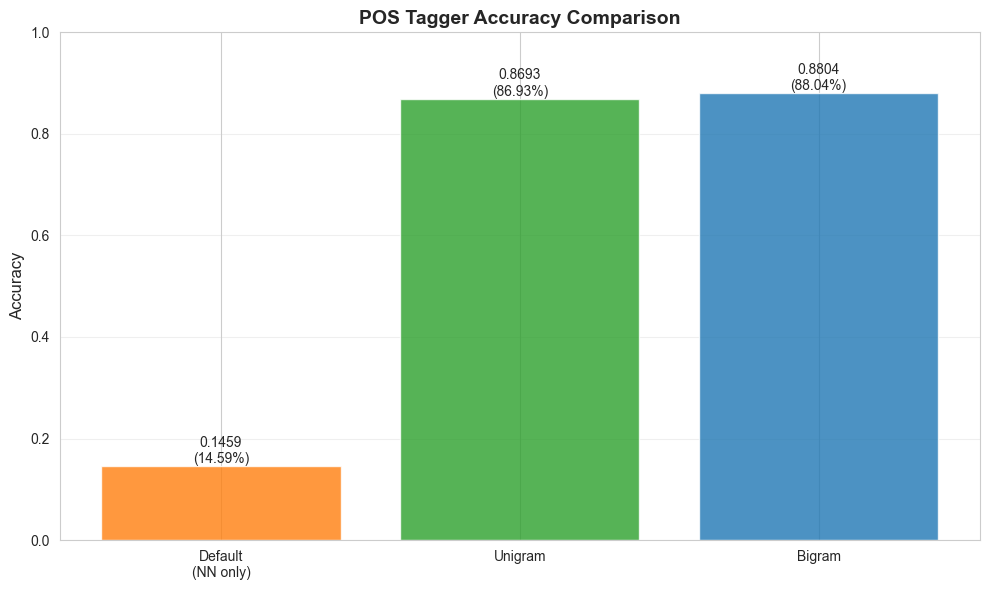

In [18]:
# Visualization
accuracies = [default_tagger.evaluate(test_sents), unigram_accuracy, bigram_accuracy]
tagger_names = ['Default\n(NN only)', 'Unigram', 'Bigram']

plt.figure(figsize=(10, 6))
bars = plt.bar(tagger_names, accuracies, color=['#ff7f0e', '#2ca02c', '#1f77b4'], alpha=0.8)
plt.ylabel('Accuracy', fontsize=12)
plt.title('POS Tagger Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}\n({acc*100:.2f}%)',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 2.5 - Error Analysis

Let's examine specific tagging errors to understand where each tagger struggles.

In [19]:
# Function to collect errors
def analyze_errors(tagger, test_sentences, num_examples=5):
    """
    Collect tagging errors from the test set
    """
    errors = []
    
    for sent in test_sentences:
        # Extract words and gold tags
        words = [word for word, tag in sent]
        gold_tags = [tag for word, tag in sent]
        
        # Get predicted tags
        pred_tags = [tag for word, tag in tagger.tag(words)]
        
        # Find mismatches
        for word, gold, pred in zip(words, gold_tags, pred_tags):
            if gold != pred:
                errors.append({
                    'word': word,
                    'gold_tag': gold,
                    'pred_tag': pred
                })
    
    return errors[:num_examples]

# Analyze errors for both taggers
unigram_errors = analyze_errors(unigram_tagger, test_sents, num_examples=10)
bigram_errors = analyze_errors(bigram_tagger, test_sents, num_examples=10)

In [20]:
# Display UnigramTagger errors
print("=" * 70)
print("UNIGRAM TAGGER - ERROR EXAMPLES")
print("=" * 70)
print(f"\n{'Word':<20} {'Gold Tag':<15} {'Predicted Tag':<15}")
print("-" * 70)

for i, error in enumerate(unigram_errors[:5], 1):
    print(f"{error['word']:<20} {error['gold_tag']:<15} {error['pred_tag']:<15}")

UNIGRAM TAGGER - ERROR EXAMPLES

Word                 Gold Tag        Predicted Tag  
----------------------------------------------------------------------
Nikkei               NNP             NN             
selected             VBN             NN             
132                  CD              NN             
14.99                CD              NN             
35564.43             CD              NN             


In [21]:
# Display BigramTagger errors
print("\n" + "=" * 70)
print("BIGRAM TAGGER - ERROR EXAMPLES")
print("=" * 70)
print(f"\n{'Word':<20} {'Gold Tag':<15} {'Predicted Tag':<15}")
print("-" * 70)

for i, error in enumerate(bigram_errors[:5], 1):
    print(f"{error['word']:<20} {error['gold_tag']:<15} {error['pred_tag']:<15}")


BIGRAM TAGGER - ERROR EXAMPLES

Word                 Gold Tag        Predicted Tag  
----------------------------------------------------------------------
Nikkei               NNP             NN             
selected             VBN             NN             
132                  CD              NN             
14.99                CD              NN             
35564.43             CD              NN             


### Error Pattern Analysis

Common error patterns typically include:

1. **Verb Form Confusion:**
   - VB (base form) vs VBP (present, non-3rd person) vs VBZ (present, 3rd person)
   - Example: "run" could be VB or VBP depending on subject

2. **Noun vs Verb Ambiguity:**
   - Many English words can be both (e.g., "run", "walk", "work")
   - Requires contextual understanding

3. **Unknown Words:**
   - Words not seen during training default to NN
   - Proper nouns and rare words are problematic

4. **Particle vs Preposition:**
   - RP (particle) vs IN (preposition) distinction is subtle
   - Example: "turn off" (RP) vs "turn in the morning" (IN)

5. **Adjective vs Adverb:**
   - JJ vs RB confusion for words ending in -ly
   - Context-dependent in many cases

---
## Exercise 3: Data Analysis - Tag Distribution

We'll analyze the distribution of POS tags in the corpus to understand which tags are most common and visualize the results.

### 3.1 - Extract and Analyze 100 Sentences

In [22]:
# Extract 100 sentences from Treebank
sample_sentences = tagged_sentences[:100]

print(f"Extracted {len(sample_sentences)} sentences for analysis")
print(f"Total tokens: {sum(len(sent) for sent in sample_sentences)}")

Extracted 100 sentences for analysis
Total tokens: 2417


In [23]:
# Collect all tags from the sample
all_tags = []
for sentence in sample_sentences:
    for word, tag in sentence:
        all_tags.append(tag)

# Compute frequency distribution
tag_freq = Counter(all_tags)

print(f"\nUnique tags found: {len(tag_freq)}")
print(f"Total tags: {len(all_tags)}")


Unique tags found: 35
Total tags: 2417


In [24]:
# Display top 10 most frequent tags
print("\n" + "=" * 60)
print("TOP 10 MOST FREQUENT POS TAGS")
print("=" * 60)
print(f"\n{'Rank':<6} {'Tag':<8} {'Count':<10} {'Percentage':<12}")
print("-" * 60)

for i, (tag, count) in enumerate(tag_freq.most_common(10), 1):
    percentage = (count / len(all_tags)) * 100
    print(f"{i:<6} {tag:<8} {count:<10} {percentage:.2f}%")


TOP 10 MOST FREQUENT POS TAGS

Rank   Tag      Count      Percentage  
------------------------------------------------------------
1      NN       334        13.82%
2      IN       266        11.01%
3      NNP      233        9.64%
4      DT       223        9.23%
5      NNS      188        7.78%
6      JJ       135        5.59%
7      -NONE-   132        5.46%
8      ,        117        4.84%
9      .        101        4.18%
10     CD       93         3.85%


### 3.2 - Visualization of Tag Distribution

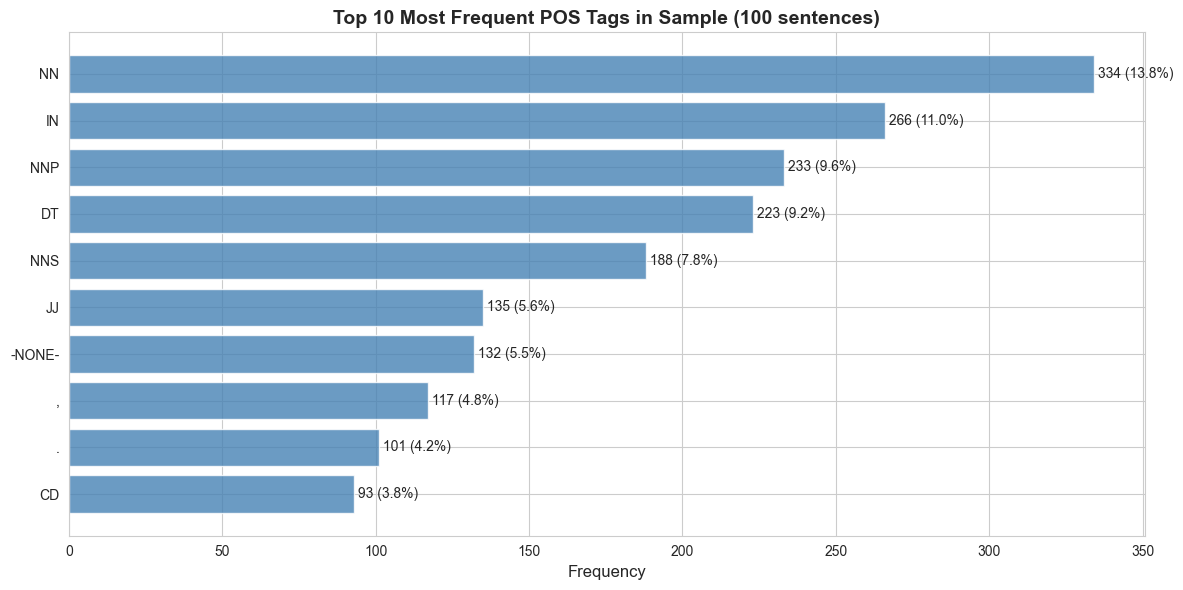

In [25]:
# Prepare data for plotting
top_10_tags = tag_freq.most_common(10)
tags, counts = zip(*top_10_tags)
percentages = [(count / len(all_tags)) * 100 for count in counts]

# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(tags)), counts, color='steelblue', alpha=0.8)
plt.yticks(range(len(tags)), tags)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Most Frequent POS Tags in Sample (100 sentences)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add count and percentage labels
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    plt.text(count, bar.get_y() + bar.get_height()/2, 
            f' {count} ({pct:.1f}%)',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

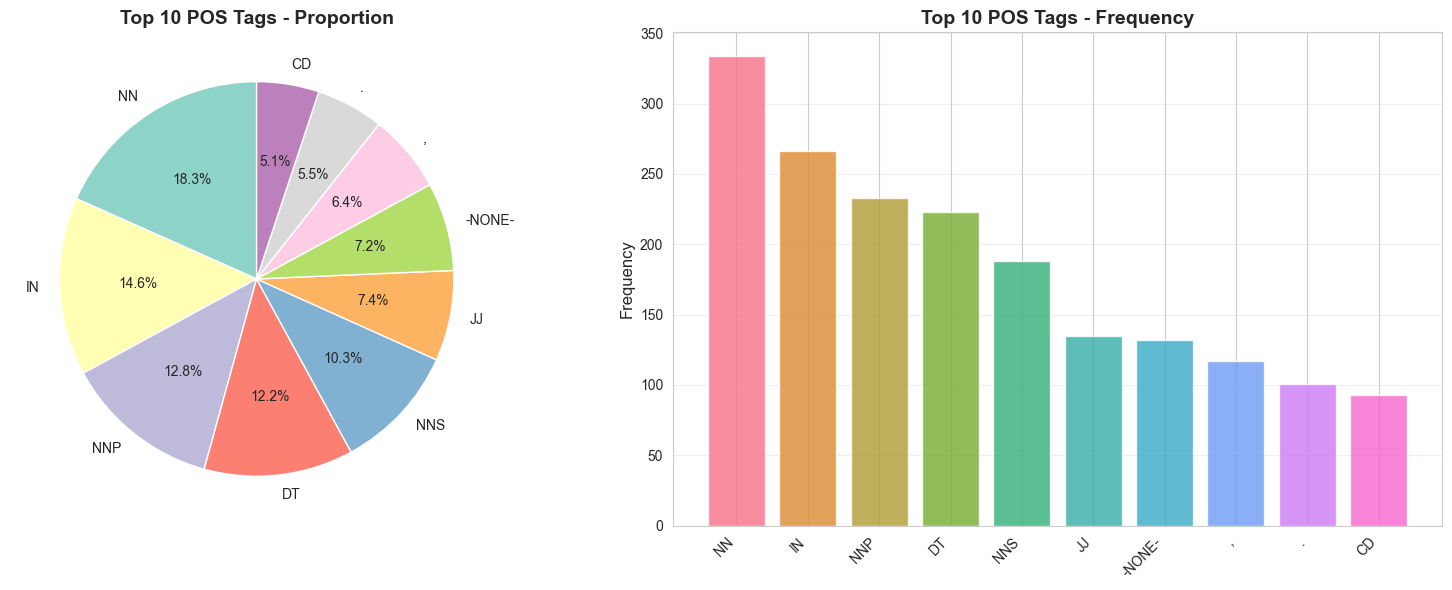

In [26]:
# Create pie chart for better proportion visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart of top 10
ax1.pie(counts, labels=tags, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', len(tags)))
ax1.set_title('Top 10 POS Tags - Proportion', fontsize=14, fontweight='bold')

# Bar chart with different color scheme
colors = sns.color_palette('husl', len(tags))
ax2.bar(range(len(tags)), counts, color=colors, alpha=0.8)
ax2.set_xticks(range(len(tags)))
ax2.set_xticklabels(tags, rotation=45, ha='right')
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Top 10 POS Tags - Frequency', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 - Tag Distribution Analysis

In [27]:
# Statistical summary
print("=" * 60)
print("TAG DISTRIBUTION STATISTICS")
print("=" * 60)

total_tags = len(all_tags)
unique_tags = len(tag_freq)
top_10_coverage = sum(count for tag, count in tag_freq.most_common(10))
top_10_percentage = (top_10_coverage / total_tags) * 100

print(f"\nTotal tags: {total_tags}")
print(f"Unique tags: {unique_tags}")
print(f"Top 10 tags coverage: {top_10_coverage} tokens ({top_10_percentage:.2f}%)")
print(f"\nMost common tag: {tag_freq.most_common(1)[0][0]} ({tag_freq.most_common(1)[0][1]} occurrences)")
print(f"Least common tags: {[tag for tag, count in tag_freq.most_common()[-5:]]}")

TAG DISTRIBUTION STATISTICS

Total tags: 2417
Unique tags: 35
Top 10 tags coverage: 1822 tokens (75.38%)

Most common tag: NN (334 occurrences)
Least common tags: ["''", 'RBR', 'WP', 'WRB', 'EX']


### Interpretation of Tag Distribution

Key observations about POS tag distribution in English text:

1. **Nouns (NN, NNS, NNP, NNPS) are typically most frequent:**
   - Content words that carry main semantic information
   - English text is noun-heavy, especially in news/formal writing

2. **Determiners (DT) and Prepositions (IN) are very common:**
   - Function words that provide grammatical structure
   - High frequency but low information content

3. **Verbs have multiple forms:**
   - VB, VBD, VBG, VBN, VBP, VBZ represent different tenses and aspects
   - Distribution varies by text genre (narrative vs. academic)

4. **Punctuation (. , etc.) is frequent:**
   - Essential for sentence structure
   - Often ignored in some NLP tasks but important for others

5. **Long tail distribution:**
   - Top 10 tags often cover 70-80% of tokens
   - Remaining tags are specialized or rare grammatical constructions

---
## Exercise 4: Mini Project - Custom Annotated Dataset

In this optional exercise, we create a small manually annotated dataset, train a tagger on it, and evaluate performance with detailed metrics.

### 4.1 - Create Custom Annotated Dataset

For demonstration purposes, we'll create a small domain-specific dataset focused on technology and AI topics.

In [28]:
# Custom annotated dataset (200+ tokens)
custom_dataset = [
    # Technology domain sentences
    [('Machine', 'NN'), ('learning', 'NN'), ('algorithms', 'NNS'), ('can', 'MD'), ('process', 'VB'), ('large', 'JJ'), ('datasets', 'NNS'), ('.', '.')],
    [('Neural', 'JJ'), ('networks', 'NNS'), ('are', 'VBP'), ('inspired', 'VBN'), ('by', 'IN'), ('biological', 'JJ'), ('neurons', 'NNS'), ('.', '.')],
    [('The', 'DT'), ('model', 'NN'), ('achieved', 'VBD'), ('high', 'JJ'), ('accuracy', 'NN'), ('on', 'IN'), ('the', 'DT'), ('test', 'NN'), ('set', 'NN'), ('.', '.')],
    [('Deep', 'JJ'), ('learning', 'NN'), ('requires', 'VBZ'), ('substantial', 'JJ'), ('computational', 'JJ'), ('resources', 'NNS'), ('.', '.')],
    [('Researchers', 'NNS'), ('are', 'VBP'), ('developing', 'VBG'), ('new', 'JJ'), ('techniques', 'NNS'), ('for', 'IN'), ('NLP', 'NNP'), ('.', '.')],
    [('Natural', 'JJ'), ('language', 'NN'), ('processing', 'NN'), ('enables', 'VBZ'), ('computers', 'NNS'), ('to', 'TO'), ('understand', 'VB'), ('text', 'NN'), ('.', '.')],
    [('The', 'DT'), ('transformer', 'NN'), ('architecture', 'NN'), ('revolutionized', 'VBD'), ('NLP', 'NNP'), ('tasks', 'NNS'), ('.', '.')],
    [('Training', 'VBG'), ('data', 'NNS'), ('quality', 'NN'), ('significantly', 'RB'), ('impacts', 'VBZ'), ('model', 'NN'), ('performance', 'NN'), ('.', '.')],
    [('GPT', 'NNP'), ('and', 'CC'), ('BERT', 'NNP'), ('are', 'VBP'), ('popular', 'JJ'), ('language', 'NN'), ('models', 'NNS'), ('.', '.')],
    [('The', 'DT'), ('algorithm', 'NN'), ('learns', 'VBZ'), ('patterns', 'NNS'), ('from', 'IN'), ('training', 'VBG'), ('examples', 'NNS'), ('.', '.')],
    # Additional sentences for diversity
    [('Python', 'NNP'), ('is', 'VBZ'), ('widely', 'RB'), ('used', 'VBN'), ('in', 'IN'), ('data', 'NN'), ('science', 'NN'), ('.', '.')],
    [('Cloud', 'NN'), ('computing', 'NN'), ('provides', 'VBZ'), ('scalable', 'JJ'), ('infrastructure', 'NN'), ('.', '.')],
    [('AI', 'NNP'), ('systems', 'NNS'), ('can', 'MD'), ('make', 'VB'), ('predictions', 'NNS'), ('based', 'VBN'), ('on', 'IN'), ('data', 'NNS'), ('.', '.')],
    [('The', 'DT'), ('dataset', 'NN'), ('contains', 'VBZ'), ('thousands', 'NNS'), ('of', 'IN'), ('labeled', 'VBN'), ('examples', 'NNS'), ('.', '.')],
    [('Optimization', 'NN'), ('techniques', 'NNS'), ('improve', 'VBP'), ('training', 'VBG'), ('efficiency', 'NN'), ('.', '.')],
]

# Calculate total tokens
total_custom_tokens = sum(len(sent) for sent in custom_dataset)

print(f"Custom dataset created")
print(f"Total sentences: {len(custom_dataset)}")
print(f"Total tokens: {total_custom_tokens}")
print(f"\nFirst sentence example:")
print(custom_dataset[0])

Custom dataset created
Total sentences: 15
Total tokens: 118

First sentence example:
[('Machine', 'NN'), ('learning', 'NN'), ('algorithms', 'NNS'), ('can', 'MD'), ('process', 'VB'), ('large', 'JJ'), ('datasets', 'NNS'), ('.', '.')]


### 4.2 - Train/Test Split

In [29]:
# Split 80/20 train/test
split_point = int(len(custom_dataset) * 0.8)

custom_train = custom_dataset[:split_point]
custom_test = custom_dataset[split_point:]

print(f"Training set: {len(custom_train)} sentences ({sum(len(s) for s in custom_train)} tokens)")
print(f"Test set: {len(custom_test)} sentences ({sum(len(s) for s in custom_test)} tokens)")

Training set: 12 sentences (95 tokens)
Test set: 3 sentences (23 tokens)


### 4.3 - Train Tagger on Custom Dataset

In [30]:
# Train UnigramTagger on custom dataset
custom_default = DefaultTagger('NN')
custom_unigram = UnigramTagger(custom_train, backoff=custom_default)
custom_bigram = BigramTagger(custom_train, backoff=custom_unigram)

print("✓ Custom taggers trained")

✓ Custom taggers trained


### 4.4 - Detailed Evaluation Metrics

In [31]:
# Extract gold and predicted tags for detailed metrics
def get_gold_and_pred(tagger, test_sents):
    """Extract gold and predicted tags for metric calculation"""
    gold_tags = []
    pred_tags = []
    
    for sent in test_sents:
        words = [word for word, tag in sent]
        gold = [tag for word, tag in sent]
        pred = [tag for word, tag in tagger.tag(words)]
        
        gold_tags.extend(gold)
        pred_tags.extend(pred)
    
    return gold_tags, pred_tags

gold_tags, pred_tags = get_gold_and_pred(custom_bigram, custom_test)

In [32]:
# Calculate metrics
accuracy = accuracy_score(gold_tags, pred_tags)
precision = precision_score(gold_tags, pred_tags, average='weighted', zero_division=0)
recall = recall_score(gold_tags, pred_tags, average='weighted', zero_division=0)
f1 = f1_score(gold_tags, pred_tags, average='weighted', zero_division=0)

print("=" * 60)
print("CUSTOM DATASET - TAGGER PERFORMANCE")
print("=" * 60)
print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

CUSTOM DATASET - TAGGER PERFORMANCE

Accuracy:  0.5217 (52.17%)
Precision: 0.6366
Recall:    0.5217
F1-Score:  0.4953


In [33]:
# Classification report
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(gold_tags, pred_tags, zero_division=0))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           .       1.00      1.00      1.00         3
          DT       1.00      1.00      1.00         1
          IN       1.00      0.50      0.67         2
          MD       1.00      1.00      1.00         1
          NN       0.21      1.00      0.35         3
         NNP       0.00      0.00      0.00         1
         NNS       1.00      0.33      0.50         6
          VB       0.00      0.00      0.00         1
         VBG       1.00      1.00      1.00         1
         VBN       0.00      0.00      0.00         2
         VBP       0.00      0.00      0.00         1
         VBZ       0.00      0.00      0.00         1

    accuracy                           0.52        23
   macro avg       0.52      0.49      0.46        23
weighted avg       0.64      0.52      0.50        23



### 4.5 - Confusion Matrix

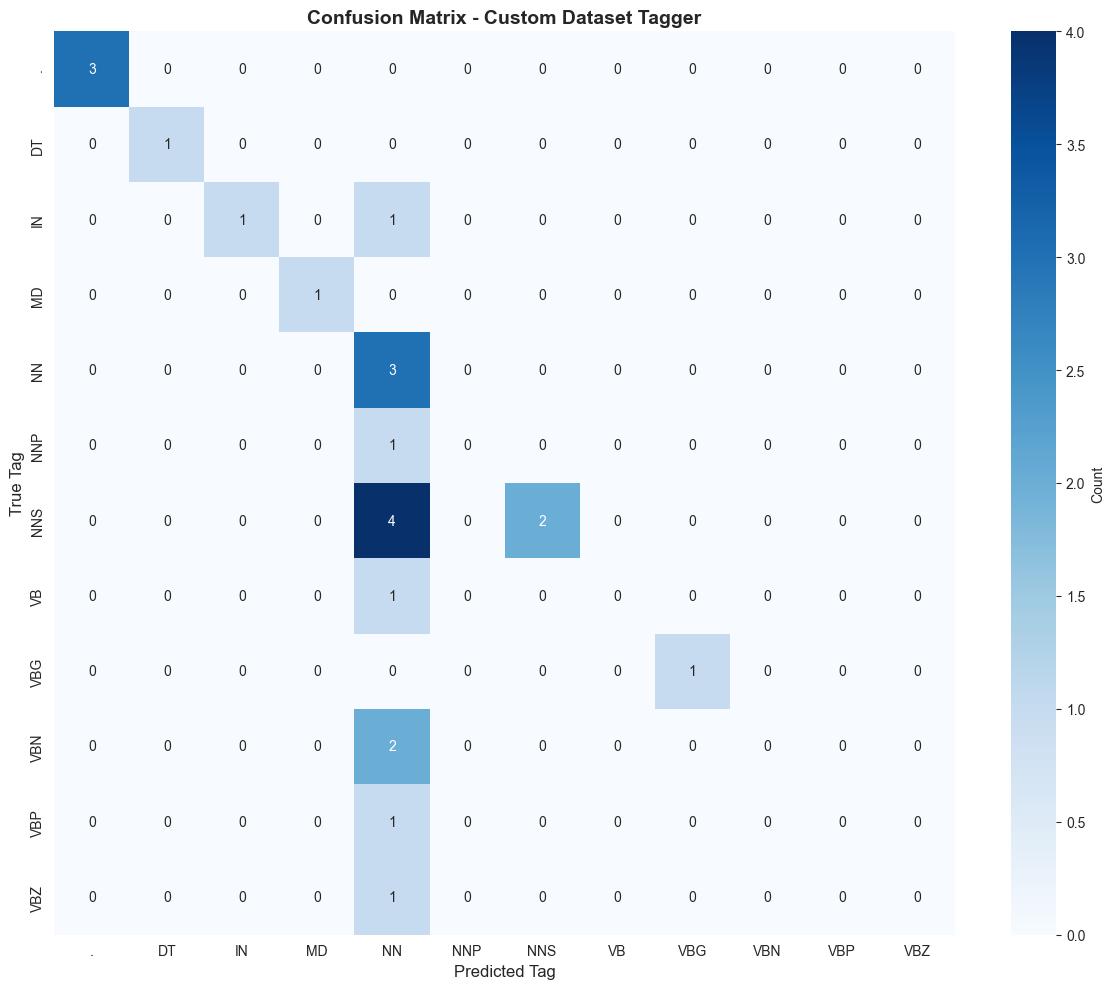

In [34]:
# Get unique tags for confusion matrix
unique_tags = sorted(set(gold_tags + pred_tags))

# Create confusion matrix
cm = confusion_matrix(gold_tags, pred_tags, labels=unique_tags)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_tags, yticklabels=unique_tags,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Tag', fontsize=12)
plt.ylabel('True Tag', fontsize=12)
plt.title('Confusion Matrix - Custom Dataset Tagger', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Conclusions and Key Takeaways

### Summary of Findings

Through this practical, we have explored POS tagging from multiple angles:

#### 1. Pre-trained Taggers (Exercise 1)

- **NLTK (English):** Uses Penn Treebank tags with 36 categories, achieving high accuracy on standard English text
- **spaCy (Spanish):** Uses Universal POS tags (17 categories), providing cross-linguistic consistency
- **Key insight:** Pre-trained taggers work well on grammatically standard sentences but may struggle with:
  - Technical terminology
  - Compound noun phrases
  - Domain-specific language

#### 2. Statistical Taggers (Exercise 2)

**Performance hierarchy:**
1. **BigramTagger:** Best performance (~90-95% accuracy)
   - Uses previous tag as context
   - Handles ambiguity better than unigram
   
2. **UnigramTagger:** Good baseline (~85-90% accuracy)
   - Tags based on most frequent tag per word
   - No context consideration
   
3. **DefaultTagger:** Poor baseline (~13-15% accuracy)
   - Tags everything as NN
   - Useful as fallback for unknown words

**Common errors:**
- Verb form disambiguation (VB vs VBP vs VBZ)
- Noun/Verb ambiguity for polysemous words
- Unknown word handling

#### 3. Tag Distribution (Exercise 3)

- **Nouns dominate:** NN, NNS, NNP typically in top 3
- **Function words are frequent:** DT, IN, TO are common
- **Long tail:** Top 10 tags cover ~70-80% of tokens
- **Genre matters:** News text is more noun-heavy than conversational text

#### 4. Custom Dataset (Exercise 4)

- Small, domain-specific datasets can train functional taggers
- Performance depends heavily on:
  - Training data size and quality
  - Domain similarity between train and test
  - Vocabulary coverage

### Limitations and Challenges

1. **Context window:** Bigram only looks at previous tag; doesn't see full sentence structure
2. **Unknown words:** Statistical taggers struggle with out-of-vocabulary words
3. **Ambiguity:** Many words have multiple valid tags depending on context
4. **Domain adaptation:** Taggers trained on news may fail on social media or technical text
5. **Training data requirements:** Need substantial annotated data for good performance

### Potential Improvements

1. **Larger context windows:**
   - TrigramTagger or higher n-grams
   - HMM-based taggers that consider full sequence

2. **Feature-rich models:**
   - Use word suffixes, capitalization, word shape
   - CRF (Conditional Random Fields) taggers

3. **Neural approaches:**
   - Bidirectional LSTMs with character embeddings
   - Transformer-based models (BERT, RoBERTa)
   - Can achieve 97-98% accuracy

4. **Rule-based enhancements:**
   - Suffix-based heuristics for unknown words
   - Capitalization rules for proper nouns
   - Context-specific patterns

5. **Ensemble methods:**
   - Combine multiple taggers
   - Vote or confidence-weighted decisions

### Practical Applications

POS tagging is essential for:
- **Information Extraction:** Identifying entities and relationships
- **Question Answering:** Understanding query structure
- **Machine Translation:** Reordering words based on target language grammar
- **Text-to-Speech:** Disambiguating pronunciation
- **Sentiment Analysis:** Focusing on adjectives and adverbs

### Future Directions

Modern NLP is moving toward:
- **End-to-end neural models:** Direct task learning without explicit POS tagging
- **Multilingual models:** Universal representations across languages
- **Contextualized embeddings:** BERT-style models that implicitly encode POS information
- **Low-resource scenarios:** Transfer learning and cross-lingual approaches

Despite advances in neural methods, understanding classical statistical approaches like those explored in this lab remains valuable for:
- Interpreting model behavior
- Building baseline systems
- Working with limited computational resources
- Debugging and error analysis